# Ejercicio Módulo 5 - Dataset Swiss
**Inteligencia Artificial - CEIA - FIUBA**

**SOTELO WALTER GABRIEL**

Para aprender sobre regresión, vamos a utilizar un dataset clásico llamado Swiss, que proviene originalmente del lenguaje R. Este dataset contiene datos socioeconómicos de 47 provincias suizas a fines del siglo XIX. Cada fila representa una provincia, y las variables reflejan características demográficas y sociales relevantes para ese contexto histórico.

## Variables

- `Location`: Provincia donde se midieron los datos.
- `Fertility`: Tasa de fertilidad (número promedio de hijos por mujer)
- `Agriculture`:` Porcentaje de hombres ocupados en agricultura
- `Examination`: Porcentaje de hombres que completaron exámenes de educación superior
- `Education`: Nivel promedio de educación (escala arbitraria)
- `Catholic`: Porcentaje de población católica
- `Infant.Mortality`: Tasa de mortalidad infantil (por cada 1000 nacidos vivos)

## Que queremos predecir?

Vamos a utilizar este dataset para predecir la tasa de fertilidad en cada provincia mediante diferentes métodos de regresión.

--- 

Siguiendo el procedimiento típico de Machine Learning, vamos a leer los datos y separarlos en los datasets de entrenamiento y testeo utilizando Scikit-Learn...

In [44]:
import pandas as pd

df = pd.read_csv("swiss.csv")

df.head()

,Location,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
0,Courtelary,80.2,17.0,15,12,9.96,22.2
1,Delemont,83.1,45.1,6,9,84.84,22.2
2,Franches-Mnt,92.5,39.7,5,5,93.40,20.2
3,Moutier,85.8,36.5,12,7,33.77,20.3
4,Neuveville,76.9,43.5,17,15,5.16,20.6


In [45]:
print(f"Tenemos {df.shape[0]} observaciones")

Tenemos 47 observaciones


Obtenemos la variable objetivo (`Fertility`) y, por otro lado, los atributos (quitamos `Location` ya que no es un atributo numérico relevante para la regresión)

In [46]:
X = df.drop(["Fertility", "Location"], axis=1)
y = df["Fertility"]

Dado que tenemos pocas observaciones, vamos a separar el dataset en un 50% para entrenamiento y 50% para testeo:

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

## Regresión lineal múltiple

Arranquemos la primera parte del ejercicio. Para eso, vamos a entrenar un modelo de regresión lineal múltiple usando todos los atributos. Para ello debes:

1. Escalar los atributos usando `StandardScaler`
2. Entrenar el modelo usando el dataset de entrenamiento.
3. Obtener las predicciones sobre el dataset de testeo.
4. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


##### COMPLETAR AQUI LO PEDIDO

# Definimos qué columnas son categóricas y cuáles numéricas
numerical_columns = ['Agriculture', 'Examination', 'Education', 'Catholic', 'Infant.Mortality']

# Creamos el preprocesamiento para las columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns)    # Escalamos las variables numéricas
    ]
)

# Creamos el pipeline con preprocesamiento y modelo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())  # Aplicamos la regresión lineal
])

# Corremos el pipeline con los datos de entrenamiento
pipeline.fit(X_train, y_train)
# Evaluamos el modelo con los datos de prueba
y_pred = pipeline.predict(X_test)

# Imprimimos las métricas de evaluación
print(f"R2: {r2_score(y_test, y_pred)}")
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")

R2: 0.574446291876874
MSE: 64.45719426896427
MAE: 6.093707279834093


## Modelo con regularización

Para mejorar nuestro modelo, vamos a explorar técnicas de regresión lineal con regularización, que nos permiten controlar el sobreajuste y seleccionar variables relevantes automáticamente.

Existen dos variantes muy populares:

- Una penaliza la suma de los cuadrados de los coeficientes (regularización L2).
- La otra penaliza la suma del valor absoluto de los coeficientes (regularización L1).

Ambas ayudan a mejorar la generalización, pero una de ellas además puede eliminar variables (coeficientes exactamente cero), lo que ayuda a identificar qué atributos son realmente importantes.

Tu tarea:

1. Elegí correctamente cuál de los dos métodos de regularización usar para este problema. 
    - Pista: Queremos que el modelo sea capaz de hacer una selección automática de variables, dejando fuera aquellas que no aportan.
2. Implementá un pipeline que incluya escalado y el modelo elegido.
3. Buscá automáticamente el mejor valor del hiperparámetro de regularización (alpha) usando validación cruzada usando 3-folds.
4. Entrená el modelo con los datos de entrenamiento y obtené las predicciones para el set de testeo.
5. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.
6. Imprimí los coeficientes resultantes e identificá qué variables fueron eliminadas (coeficiente = 0).

In [49]:
import numpy as np

from sklearn.linear_model import LassoCV, RidgeCV

Paremos un momento para entender qué hacen LassoCV y RidgeCV antes de continuar con la resolución:

> Tanto `LassoCV` como `RidgeCV` son implementaciones de regresión lineal con regularización que incluyen la búsqueda automática del mejor hiperparámetro alpha mediante validación cruzada.
>
> Ambos métodos prueban distintos valores de alpha y eligen el que minimiza el error del modelo, facilitando el proceso de ajuste sin necesidad de una búsqueda manual.
>
> Internamente, utilizan la métrica del error cuadrático medio (MSE) para evaluar el rendimiento del modelo en cada fold de la validación cruzada.
>
> Por ejemplo, si llamás a RidgeCV(alphas=alphas, cv=5), se hará una validación cruzada de 5 folds utilizando los valores de alpha que vos le pases, y se seleccionará el que obtenga el menor MSE promedio.
> 
> Una vez elegido el mejor alpha, el modelo final se entrena con todos los datos de entrenamiento usando ese valor.

¡Listo! Con todo lo que vimos hasta ahora, ya estás en condiciones de resolver esta parte y completar los 6 puntos propuestos

In [50]:
alphas = np.logspace(-4, 1, 500)

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_columns = ['Agriculture', 'Examination', 'Education', 'Catholic', 'Infant.Mortality']

# Creamos el preprocesamiento para las columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns)   
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

In [52]:
from sklearn.pipeline import Pipeline

numerical_columns = ['Agriculture', 'Examination', 'Education', 'Catholic', 'Infant.Mortality']

# Creamos el preprocesamiento para las columnas de ambos modelos
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns)
    ]
)
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns)
    ]
)


pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor_lasso),
    ('regressor', LassoCV(alphas=alphas, cv=5))  # Aplicamos la regresión lineal
])

pipeline_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [53]:
from sklearn.metrics import (r2_score, mean_absolute_error, 
                             mean_squared_error, root_mean_squared_error, 
                             mean_absolute_percentage_error)

# Evaluamos el modelo de Lasso
y_pred = pipeline_lasso.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Regresión de Lasso")
print("------------------")
print(f"R2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")


Regresión de Lasso
------------------
R2: 0.6044
MAE: 5.8318
MSE: 59.9180
RMSE: 7.7407
MAPE: 0.0931


R2: 0.574446291876874
MSE: 64.45719426896427
MAE: 6.093707279834093

In [54]:
## por ultimo realizamos un spearman para ver la correlacion entre las variables y la variable objetivo
from scipy.stats import spearmanr
for col in numerical_columns:
    corr, p_value = spearmanr(X[col], y)
    print(f"Correlación de Spearman entre {col} y Fertility: {corr:.4f} (p-value: {p_value:.4f})") 

Correlación de Spearman entre Agriculture y Fertility: 0.2427 (p-value: 0.1003)
Correlación de Spearman entre Examination y Fertility: -0.6609 (p-value: 0.0000)
Correlación de Spearman entre Education y Fertility: -0.4433 (p-value: 0.0018)
Correlación de Spearman entre Catholic y Fertility: 0.4136 (p-value: 0.0039)
Correlación de Spearman entre Infant.Mortality y Fertility: 0.4371 (p-value: 0.0021)


<Axes: >

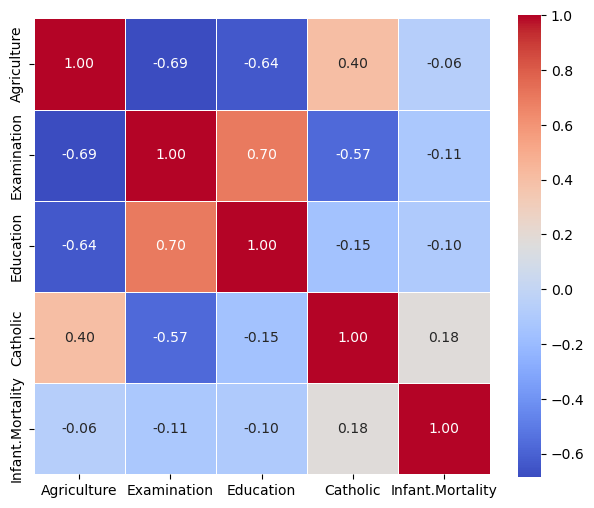

In [59]:
## Calculamos las correlaciones entre las variables numéricas 'Agriculture', 'Examination', 'Education', 'Catholic', 'Infant.Mortality'
import seaborn as sns
import matplotlib.pyplot as plt
df = X[numerical_columns].copy()
plt.figure(figsize=(25,6))
plt.subplot(1, 3, 1)
sns.heatmap(
    df[['Agriculture', 'Examination', 'Education', 'Catholic', 'Infant.Mortality']].corr(numeric_only=False), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    cbar=True,  
    square=True,  
    linewidths=0.5,  
    linecolor='white'  
)   



## Comparación de modelos y conclusiones

Completá la siguiente tabla con las métricas obtenidas para cada uno de los modelos que entrenaste:

| Modelo                        | MAE | MSE | $R^2$ |
| ----------------------------- | --- | --- | ----- |
| Regresión Lineal              |6.094|64.46|  0.57 |
| Modelo Regularizado (Lasso  ) |5.831|59.92|  0.64 |


> ⚠️ Asegurate de cambiar el nombre del modelo `Modelo Regularizado (L1 o L2)` según el modelo que usaste (Lasso o Ridge).

### Justificación

**¿Cuál de los modelos te parece que tuvo un mejor desempeño general?**

Tené en cuenta las tres métricas al responder, y también pensá en la complejidad del modelo (por ejemplo, si eliminó variables innecesarias).

Escribí tu respuesta a continuación:

El mejor modelo fue Lasso, use este modelo ya que al no haber realizado un EDA, no sabia la medidas de asociación entre las variables 'Agriculture', 'Examination', 'Education', 'Catholic', 'Infant.Mortality'.

Como se puede observar mejora en las 3 metricas, lo que indica que seguramente habia una fuerte relación entre algunas variables que estaba produciendo un overfitting
Para esto calculamos los indicadores spearman, pearson entre las variables numericas y vemos que efectivamente hay fuertes correlaciones entre algunas variables que Lazzo hizo 0 sus coeficientes limpiandolas y mejorando la generalización de los datos.